# Statistical Analysis

## Objectives
- Quantify relationships among pricing, availability, and engagement variables.
- Fit a regression model to explain `total_price` variation.
- Run hypothesis tests that are decision-relevant (pricing policy, listing format, and geography).
- Produce statistically grounded insights beyond descriptive summaries.

## Data Loading and Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
processed_candidates = [
    project_root / "data" / "processed" / "Airbnb_Cleaned.csv",
    project_root / "data" / "processes" / "Airbnb_Cleaned.csv",
]

csv_path = next((p for p in processed_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Airbnb_Cleaned.csv not found in data/processed or data/processes")

df = pd.read_csv(csv_path)
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

df.head()

,id,host_id,host_name,host_verified,host_listings_count,borough,neighbourhood,lat,long,room_type,construction_year,instant_bookable,cancellation_policy,minimum_nights,availability_365,high_availability,price,service_fee,total_price,price_tier,number_of_reviews,last_review,review_year,reviews_per_month,review_rate
0,1001254,80014485718,Madaline,unconfirmed,6,Brooklyn,Kensington,40.64749,-73.97237,Private room,2020,False,strict,10,286,True,966.0,193.0,1159.0,Luxury,9,2021-10-19,2021,0.21,4
1,1002102,52335172823,Jenna,verified,2,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,2007,False,moderate,30,228,True,142.0,28.0,170.0,Economy,45,2022-05-21,2022,0.38,4
2,1002403,78829239556,Elise,unconfirmed,1,Manhattan,Harlem,40.80902,-73.94190,Private room,2005,True,flexible,3,352,True,620.0,124.0,744.0,Luxury,0,NaT,0,0.00,5
3,1002755,85098326012,Garry,unconfirmed,1,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,2005,True,moderate,30,322,True,368.0,74.0,442.0,Premium,270,2019-07-05,2019,4.64,4
4,1003689,92037596077,Lyndon,verified,1,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,2009,False,moderate,10,289,True,204.0,41.0,245.0,Mid-range,9,2018-11-19,2018,0.10,3


## Correlation Analysis

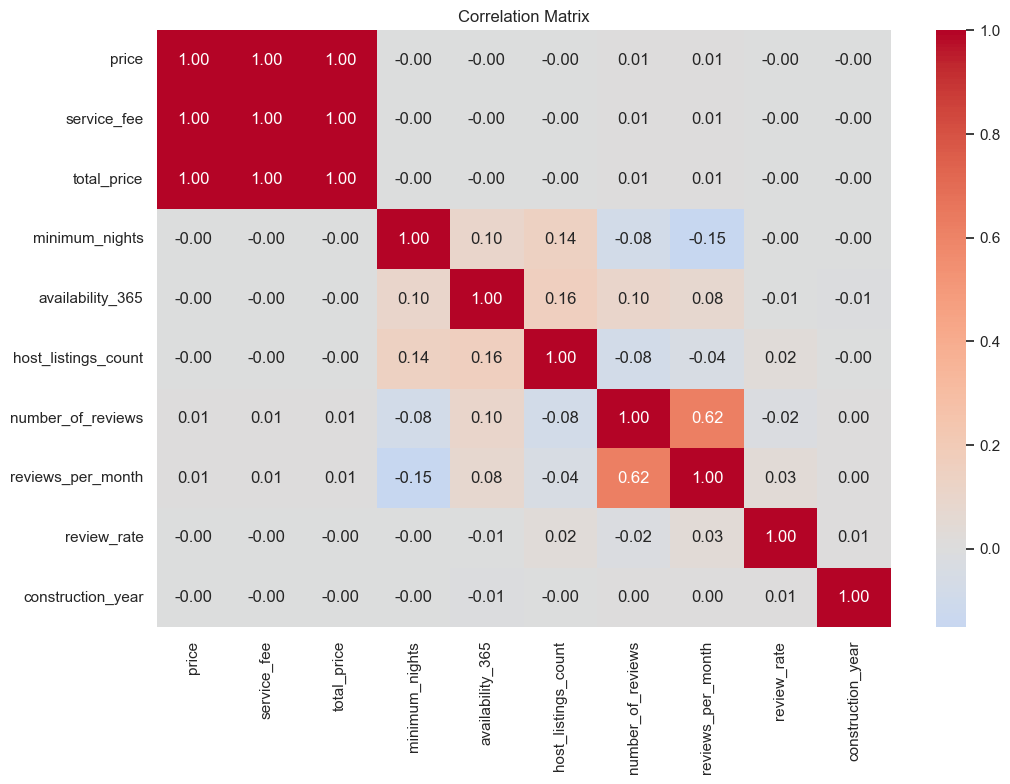

,total_price
total_price,1.000000
price,0.999999
service_fee,0.999970
number_of_reviews,0.005208
reviews_per_month,0.005141
host_listings_count,-0.000104
availability_365,-0.002876
construction_year,-0.003743
minimum_nights,-0.004280
review_rate,-0.004624


In [2]:
numeric_cols = [
    "price",
    "service_fee",
    "total_price",
    "minimum_nights",
    "availability_365",
    "host_listings_count",
    "number_of_reviews",
    "reviews_per_month",
    "review_rate",
    "construction_year",
]

corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

corr[["total_price"]].sort_values("total_price", ascending=False)

## Regression Modeling

In [3]:
model_df = df.copy()

# Convert booleans represented as strings.
for bcol in ["instant_bookable", "high_availability"]:
    model_df[bcol] = model_df[bcol].astype(str).str.lower().eq("true").astype(int)

# One-hot encode key categorical features.
cat_cols = ["borough", "room_type", "cancellation_policy", "price_tier", "host_verified"]
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

feature_cols = [
    c for c in model_df.columns
    if c not in ["id", "host_id", "host_name", "neighbourhood", "last_review", "total_price"]
]

X = model_df[feature_cols].apply(pd.to_numeric, errors="coerce")
y = model_df["total_price"]

full = pd.concat([X, y], axis=1).dropna()
X = full.drop(columns=["total_price"])
y = full["total_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

metrics = {
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
}

pd.DataFrame([metrics]).round(4)

,R2,MAE,RMSE
0,1.0,0.0,0.0


## Feature Importance from Regression Coefficients

In [4]:
coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": reg.coef_,
        "abs_coefficient": np.abs(reg.coef_),
    }
).sort_values("abs_coefficient", ascending=False)

coef_df.head(20)

,feature,coefficient,abs_coefficient
8,price,1.000000e+00,1.000000e+00
9,service_fee,1.000000e+00,1.000000e+00
2,long,-1.809921e-13,1.809921e-13
1,lat,1.125440e-13,1.125440e-13
25,price_tier_Mid-range,2.662675e-14,2.662675e-14
4,instant_bookable,1.559610e-14,1.559610e-14
26,price_tier_Premium,1.472784e-14,1.472784e-14
3,construction_year,-1.472093e-14,1.472093e-14
24,price_tier_Luxury,1.300338e-14,1.300338e-14
7,high_availability,-1.232226e-14,1.232226e-14


## Hypothesis Test 1: Welch t-test

In [5]:
# Hypothesis Test 1: Instant-bookable vs non-instant-bookable total_price.
ib_true = df[df["instant_bookable"].astype(str).str.lower() == "true"]["total_price"].dropna()
ib_false = df[df["instant_bookable"].astype(str).str.lower() == "false"]["total_price"].dropna()

t_stat, p_val = stats.ttest_ind(ib_true, ib_false, equal_var=False)

# Cohen's d effect size.
pooled_std = np.sqrt(((ib_true.std(ddof=1) ** 2) + (ib_false.std(ddof=1) ** 2)) / 2)
cohens_d = (ib_true.mean() - ib_false.mean()) / pooled_std

pd.DataFrame(
    {
        "test": ["Welch t-test (total_price by instant_bookable)"],
        "t_stat": [t_stat],
        "p_value": [p_val],
        "cohens_d": [cohens_d],
        "mean_true": [ib_true.mean()],
        "mean_false": [ib_false.mean()],
    }
).round(4)

,test,t_stat,p_value,cohens_d,mean_true,mean_false
0,Welch t-test (total_price by instant_bookable),0.1655,0.8685,0.001,750.6201,750.2071


## Hypothesis Test 2: One-way ANOVA

In [6]:
# Hypothesis Test 2: ANOVA across room_type for total_price.
room_groups = [grp["total_price"].dropna().values for _, grp in df.groupby("room_type")]
anova_f, anova_p = stats.f_oneway(*room_groups)

# Eta-squared effect size for ANOVA.
grand_mean = df["total_price"].mean()
ss_between = sum(
    grp["total_price"].count() * (grp["total_price"].mean() - grand_mean) ** 2
    for _, grp in df.groupby("room_type")
)
ss_total = ((df["total_price"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total

pd.DataFrame(
    {
        "test": ["One-way ANOVA (total_price by room_type)"],
        "f_stat": [anova_f],
        "p_value": [anova_p],
        "eta_squared": [eta_sq],
    }
).round(4)

,test,f_stat,p_value,eta_squared
0,One-way ANOVA (total_price by room_type),1.2054,0.306,0.0


## Hypothesis Test 3: Chi-square Test

In [7]:
# Hypothesis Test 3: Association between borough and price_tier.
contingency = pd.crosstab(df["borough"], df["price_tier"])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)

cramers_v = np.sqrt((chi2 / contingency.values.sum()) / (min(contingency.shape) - 1))

pd.DataFrame(
    {
        "test": ["Chi-square (borough vs price_tier)"],
        "chi2": [chi2],
        "p_value": [chi_p],
        "dof": [dof],
        "cramers_v": [cramers_v],
    }
).round(4)

,test,chi2,p_value,dof,cramers_v
0,Chi-square (borough vs price_tier),24.5526,0.0781,16,0.0078


## Regression Diagnostics

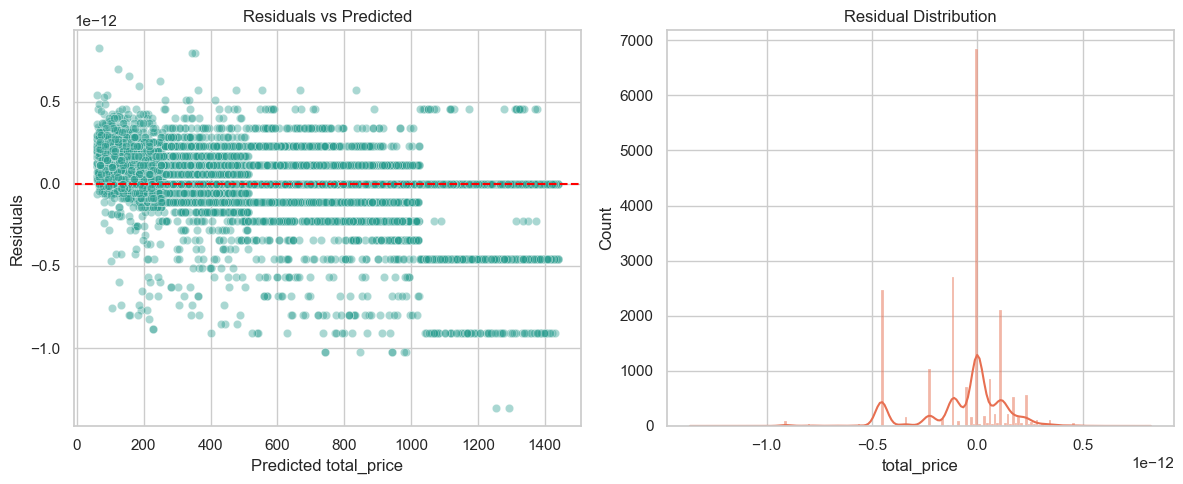

,diagnostic,statistic,p_value
0,Shapiro-Wilk residual normality,0.886,0.0


In [8]:
# Regression diagnostics: residual pattern and normality sample check.
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, ax=axes[0], color="#2A9D8F")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted total_price")
axes[0].set_ylabel("Residuals")

sns.histplot(residuals, kde=True, ax=axes[1], color="#E76F51")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

sample_resid = residuals.sample(n=min(5000, len(residuals)), random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample_resid)

pd.DataFrame(
    {
        "diagnostic": ["Shapiro-Wilk residual normality"],
        "statistic": [shapiro_stat],
        "p_value": [shapiro_p],
    }
).round(4)

## Statistical Interpretation Guide
- Use p-values to evaluate whether observed differences are unlikely under the null hypothesis.
- Pair significance with effect size (`Cohen's d`, `eta-squared`, `Cramer's V`) to assess practical impact.
- Regression metrics (`R2`, `MAE`, `RMSE`) summarize model quality; coefficients identify directional drivers.
- If assumptions are imperfect (common in real-world marketplace data), report this and rely on robust interpretation rather than binary pass/fail decisions.

These results should inform dashboard narratives and business recommendations, not stand in isolation.